# 4. Neural Networks

We use `pytorch` to implement a neural network that detectes periodicty.

It seems CNNs and RNNs are best suited for the task, we opt for a CNN here since we start with simple pattern detection: periodicity in the lightcurve. For evolving periods, an RNN would do probably do better, but we are keeping it simple for now.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

#### Prep data (run once)

We preprocess as if we were using real data. In the case of lightcurves, we subtract by mean and normalize with the variance of the data. 

With real observations, we would also have to include redshift $z$ information since different the lightcurves of an AGN appear different depending on the wavelengths. For example, reprocessed light from the outer, cooler regions of the accretion disk is redder and has a smoother lightcurve (like a blurring convolution due to transfer function). We can de-redshift the data, but we would still have to account for the corresponding range of observed wavelegth bands. The model would effectively have to learn the transfer function.

For simplicity, we use simulated data that can be easily labelled for training and validation.

In [2]:
n_lightcurves = 10000 # nbr of lightcurves to be generated

In [ ]:
# GENERATE NORMALIZED LIGHTCURVES
from eztaox.kernels.quasisep import Exp
from eztaox.simulator import UniVarSim
from eztaox.ts_utils import add_noise
from scipy.signal import sawtooth, chirp

frac_sine =  0.2 # sine periodicity
frac_quasi = 0.2 # changing sine quasi-periodicity (decaying period)
frac_saw =   0.2 # sawtooth periodicity
frac_none =  1.0 - (frac_sine + frac_quasi + frac_saw) # no periodicity

all_lightcurves = [] # time-series data
all_labels = [] # label corresponding to periocity class (0:none, 1:sine, 2:quasi, 3:saw)
all_freqs = []

min_dt, max_dt = 1.0, 3650.0 # days
logTau = np.random.uniform(np.log(10), np.log(30), size=n_lightcurves) # DRW timescale
logSigma = np.random.uniform(np.log(0.01), np.log(1.0), size=n_lightcurves) # signal variance 

for i in range(n_lightcurves):
    # setup single band DRW lightcurve model
    sim_params = {"log_kernel_param": jnp.asarray([logTau[i], logSigma[i]])}
    k = Exp(*sim_params["log_kernel_param"]) # DRW kernel 
    s = UniVarSim(k, min_dt, max_dt, sim_params) # simulator

    # simulate DRW light curve, add noise
    sim_t, sim_y = s.random(500, jax.random.PRNGKey(i), jax.random.PRNGKey(i+100))
    sim_yerr = jnp.ones_like(sim_t) * 0.05
    sim_y = add_noise(sim_y, sim_yerr, jax.random.PRNGKey(i+200))

    sim_t = np.array(sim_t)
    sim_y = np.array(sim_y)
    sim_yerr = np.array(sim_yerr)

    # index to decide the periodicity class 
    r = i/n_lightcurves

    if r < frac_sine:
        # add sine periodicity to drw
        freq = np.random.uniform(1/500, 1/100)  # period [100,500] days
        amp = np.std(sim_y) ## arbitrarily chosen
        sine = amp * np.sin(2 * np.pi * freq * sim_t)
        sim_y = sim_y + sine
        label = 1
    elif r < (frac_sine + frac_quasi):
        # add decaying sine quasi-periodicity to drw
        freq = np.random.uniform(1/500, 1/100)  # period [100,500] days
        amp = np.std(sim_y) ## arbitrarily chosen
        quasi = amp * chirp(sim_t, f0=freq/2, t1=sim_t.max(), f1=freq)
        sim_y = sim_y + quasi
        label = 2
    elif r < (frac_sine + frac_quasi + frac_saw):
        # add sawtooth periodicity to drw
        freq = np.random.uniform(1/500, 1/100)  # period [100,500] days
        amp = np.std(sim_y) ## arbitrarily chosen
        saw = amp * sawtooth(2 * np.pi * freq * sim_t)
        sim_y = sim_y + saw
        label = 3
    else:
        freq = 0.0
        label = 0

    # normalize
    sim_y = (sim_y - np.mean(sim_y)) / np.std(sim_y)
    
    all_lightcurves.append((sim_t, sim_y, sim_yerr))
    all_labels.append(label)
    all_freqs.append(freq)

In [ ]:
# save compressed data
t_arr = np.stack([lc[0] for lc in all_lightcurves])
y_arr = np.stack([lc[1] for lc in all_lightcurves])
yerr_arr = np.stack([lc[2] for lc in all_lightcurves])

labels = np.array(all_labels)
freqs = np.array(all_freqs)

np.savez_compressed(
    "lightcurves_dataset.npz",
    t=t_arr,
    y=y_arr,
    yerr=yerr_arr,
    labels=labels,
    freqs=freqs
)

#### Training and validation datasets

1. Load compressed data and suffle 
2. Split into training (80%) and validation (20%) datasets
3. Format for `pytorch`

In [3]:
# load compressd data
data = np.load("lightcurves_dataset.npz")

t = data["t"]
y = data["y"]
yerr = data["yerr"]
labels = data["labels"]
freqs = data["freqs"]

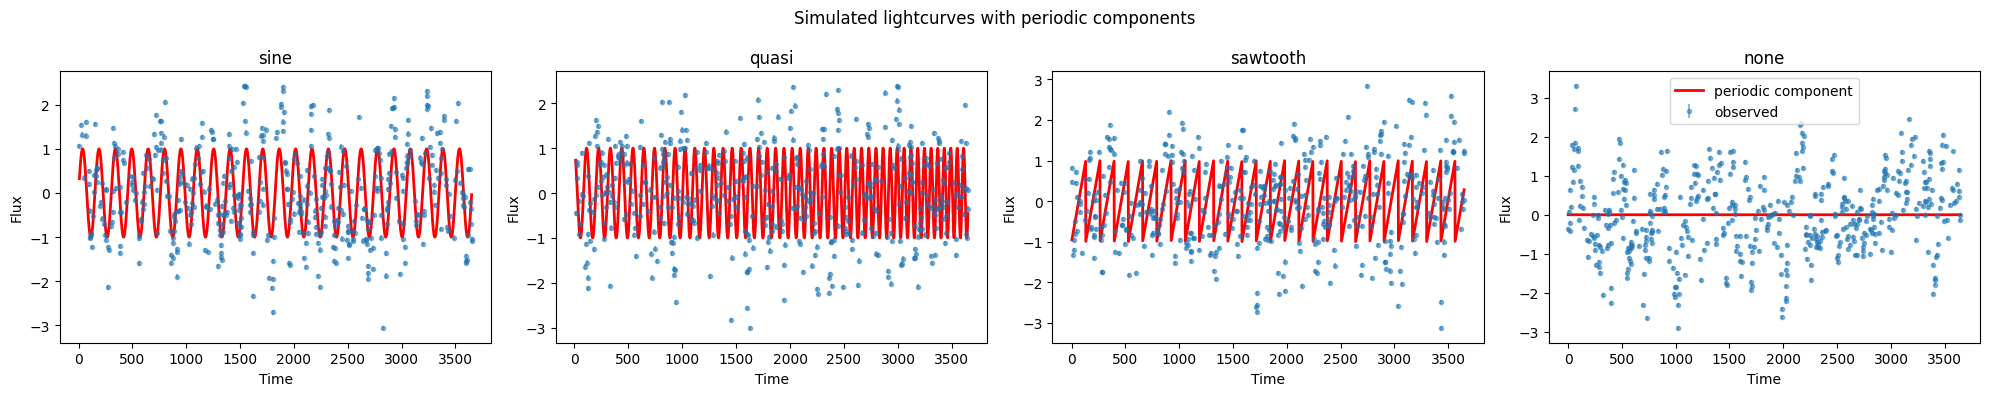

In [4]:
# visualize data (approximate bc i didnt save all the params)
from scipy.signal import sawtooth, chirp

_labels = ["sine", "quasi", "sawtooth", "none"]
_indices = (np.array([0.1, 0.3, 0.5, 0.8]) * n_lightcurves).astype(int)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, idx, label in zip(axes, _indices, _labels):
    _t = t[idx]
    _y = y[idx]
    _yerr = yerr[idx]
    _freq = freqs[idx]

    ax.errorbar(_t, _y, yerr=_yerr, fmt='.', alpha=0.5, label="observed") # observed data

    # evenly sampled time grid for superposed signal
    t_smooth = np.linspace(_t.min(), _t.max(), 2000)
    amp = 1.0 #np.std(y)

    if label == "sine":
        y_model = amp * np.sin(2*np.pi*_freq*t_smooth)
    elif label == "quasi":
        y_model = amp * chirp(t_smooth, f0=_freq, f1=_freq * 2, t1=t_smooth.max())
    elif label == "sawtooth":
        y_model = amp * sawtooth(2*np.pi*_freq*t_smooth)
    else:
        y_model = np.zeros_like(t_smooth)

    ax.plot(t_smooth, y_model, color='red', lw=2, label="periodic component")

    ax.set_title(label)
    ax.set_xlabel("Time"); ax.set_ylabel("Flux")

plt.suptitle("Simulated lightcurves with periodic components")
plt.tight_layout()
plt.legend()
plt.show()

In [7]:
# ensure uneven sampling dt is being properly considered
X = np.array([np.stack([y[i], # flux
                        np.insert(np.diff(t[i]), 0, 0.0) # sampling rate
                       ], axis=0) for i in range(len(y))])
y_labels = labels

In [8]:
# split suffled data into training and validation datasets

# X already built via interpolation step
# X shape: (N, T), labels shape: (N,)

N = len(X)
idx = np.random.permutation(N) # shuffle
split = int(0.8 * N) # split 80% training, 20% validation

train_idx = idx[:split]
val_idx = idx[split:]

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y_labels[train_idx], y_labels[val_idx]

In [9]:
class LightCurveDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [10]:
from torch.utils.data import DataLoader

train_dataset = LightCurveDataset(X_train, y_train)
val_dataset = LightCurveDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

#### CNN model

Most of this section comes from following [the Moodle example](https://github.com/LSSTC-DSFP/Session-19/blob/main/day3/ConvolutionalNeuralNetworks.ipynb).

In [11]:
import torch.nn as nn
import torch.nn.functional as F

class LightCurveCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # convolutional + batch normalization layers
        # (kernels of different size should find features of different scales: small=local)
        # (padding keeps edge info and )
        # (batch norm are included in every online example... it seems to act a bit like regularization )
        # ReLU activation function
        self.conv1 = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=7, padding=3), # channel 0: flux, channel 1: dt
            nn.BatchNorm1d(32),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=31, padding=15),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        self.pool = nn.MaxPool1d(2)

        # collapse to 1d time?
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # classifier: fully connected layers + output
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 4)  # 4 classes (logits)
        # dont need to use softmax bc its included in how CrossEntropyLoss is calculates

    def forward(self, x):
        x = self.pool(self.conv1(x))
        x = self.pool(self.conv2(x))
        x = self.pool(self.conv3(x))
        x = self.global_pool(x) # (batch, 128,1)
        x = x.squeeze(-1) # (batch, 128)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x) 

        return x

#### Train and validate CNN

In [12]:
torch.cuda.is_available()

False

In [13]:
device = torch.device("cpu")

model = LightCurveCNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [14]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        preds = model(x)
        loss = criterion(preds, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader) # loss

In [15]:
def eval_model(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device) # x: input, y: label
            preds = model(x) # output logit
            pred_labels = preds.argmax(dim=1) # output label

            # calculate accuracy
            correct += (pred_labels == y).sum().item()
            total += y.size(0)

    return correct / total

In [16]:
epochs = 20

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader)
    val_acc = eval_model(model, val_loader)

    print(f"Epoch {epoch+1}: training loss={train_loss:.4f}, validation accuracy={val_acc:.4f}")

Epoch 1: training loss=1.1860, validation accuracy=0.3940
Epoch 2: training loss=0.7969, validation accuracy=0.2120
Epoch 3: training loss=0.5979, validation accuracy=0.4275
Epoch 4: training loss=0.4727, validation accuracy=0.6645
Epoch 5: training loss=0.3988, validation accuracy=0.4160
Epoch 6: training loss=0.3328, validation accuracy=0.6390
Epoch 7: training loss=0.2788, validation accuracy=0.3080
Epoch 8: training loss=0.2211, validation accuracy=0.5885
Epoch 9: training loss=0.1858, validation accuracy=0.4045
Epoch 10: training loss=0.1384, validation accuracy=0.6395
Epoch 11: training loss=0.1055, validation accuracy=0.3620
Epoch 12: training loss=0.0923, validation accuracy=0.6760
Epoch 13: training loss=0.0721, validation accuracy=0.3930
Epoch 14: training loss=0.0504, validation accuracy=0.6850
Epoch 15: training loss=0.0428, validation accuracy=0.5735
Epoch 16: training loss=0.0395, validation accuracy=0.7065
Epoch 17: training loss=0.0291, validation accuracy=0.7530
Epoch 

Training loss steadily goes down, but validation accuracy is really unstable and not improving over time... could be validation data is not well represented in training data, or one of the classes is hard to learn: we check the confusion matrix.

> note: I tried a couple fixes like increasing the amount of data, adding dt as an input channel (this is something CNNs can struggle with), and adding depth to the NN, but they made it **worse**.

The validation doing so poorly is a very bad sign that variance isnt improving, and that only bias is being lowered.

In [21]:
torch.save(model.state_dict(), "v4_lightcurve_cnn.pth")

#### Diagnostics 

For classification, confusion matrix is most telling:

In [18]:
model = LightCurveCNN()
model.load_state_dict(torch.load("v4_lightcurve_cnn.pth", map_location="cpu"))

<All keys matched successfully>

Wrote my own function for confusion matrix since I was having issues downloding `sklearn` to use `confusion_matrix` from `sklearn.metrics`.
 

In [19]:
import pandas as pd

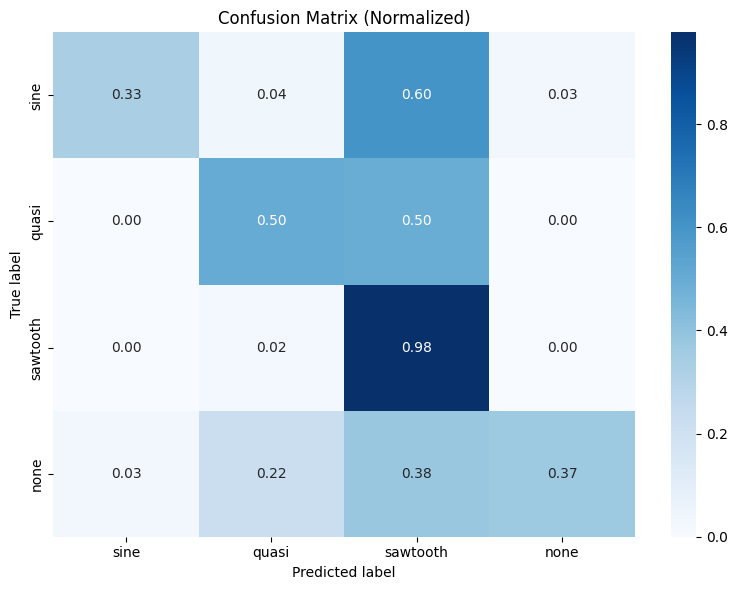

In [20]:
import seaborn as sn

y_pred = []
y_true = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs) # logit
        pred = torch.argmax(outputs, dim=1) 
        y_pred.append(pred.cpu().numpy())
        y_true.append(labels.cpu().numpy())

y_pred = np.concatenate(y_pred)
y_true = np.concatenate(y_true)


# calculate and plot confusion matrix
#cm = confusion_matrix(y_true, y_pred)

classes = ["sine", "quasi", "sawtooth", "none"]
n_classes = len(classes)

cm = np.zeros((n_classes, n_classes))
for true, pred in zip(y_true, y_pred):
    cm[true, pred] += 1
cm_norm = cm / cm.sum(axis=1, keepdims=True) # normalize

# plot confusion matrix
df_cm = pd.DataFrame(cm_norm, index=classes, columns=classes)

plt.figure(figsize=(8, 6))
sn.heatmap(df_cm, annot=True, cmap="Blues", fmt=".2f")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (Normalized)")
plt.tight_layout()
plt.show()

This looks pretty horrible. The model almost never predicts 'none' or 'sine' signals. The model instead labels things as 'sawtooth' often: very contaminated. But this also means its the labels it recovers best (98% of the time).

Every other label is correct less than 50% of the time.

Lets compare to best-performing previous model that did not have dt as input channel and just interpolated to have even sampling:

In [ ]:
data = np.load("v2_confusion_matrix.npz", allow_pickle=True)

cm = data["cm"]
cm_norm = data["cm_norm"]
classes = data["classes"].tolist()

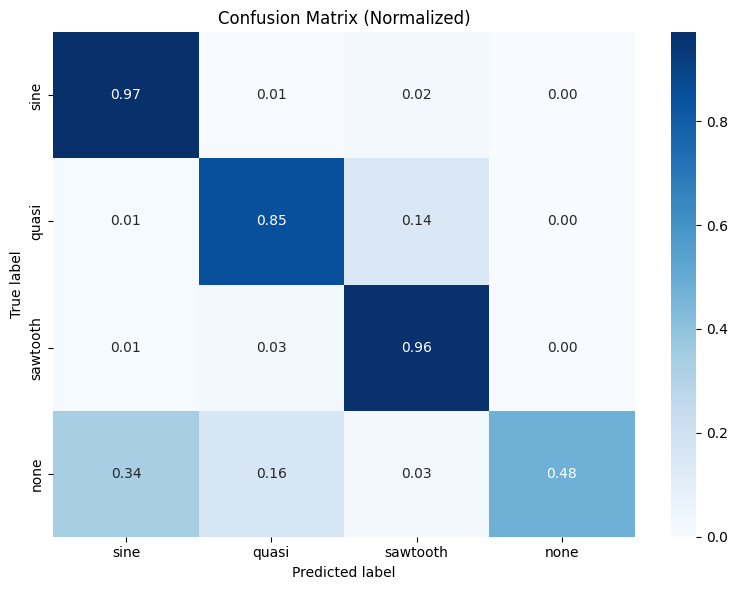

In [35]:
# calculate and plot confusion matrix
#cm = confusion_matrix(y_true, y_pred)

data = np.load("v2_confusion_matrix.npz", allow_pickle=True)

cm = data["cm"]
cm_norm = data["cm_norm"]
classes = data["classes"].tolist()

# plot confusion matrix
df_cm = pd.DataFrame(cm_norm, index=classes, columns=classes)

plt.figure(figsize=(8, 6))
sn.heatmap(df_cm, annot=True, cmap="Blues", fmt=".2f")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (Normalized)")
plt.tight_layout()
plt.show()

Although this looks much better, signals with no periodic component are being mistaken for sines -- something the current model isnt doing because its always guessing 'sawtooth'... so i guess that problem got solved hahah. I linked the previous notebook as `Q4_extra.ipynb` since it performs so much better despite this one seeming more rigourous.